1. Setup and Imports

In [46]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

2. The Abstract Problem Interface

In [47]:
class Problem(ABC):
    @abstractmethod
    def initial_state(self) -> Any:
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        pass

3. The Node Class

In [48]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

4. Helper Functions

In [49]:
def reconstruct_path(node: Node) -> List[Any]:
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    while node is not None:
        if node.state == state:
            return True
        node = node.parent
    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    return pd.DataFrame([result_to_row(r) for r in results])

5. Implementing the Grid Search Problem

In [50]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_actions = []
        row, col = state
        for action, (dr, dc) in MOVES.items():
            neighbour = (row + dr, col + dc)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)

        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")

5.1 Self-Check for GridProblem

In [51]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


6. Sample Drone Map

In [52]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

7. Visualisation Helper

In [53]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

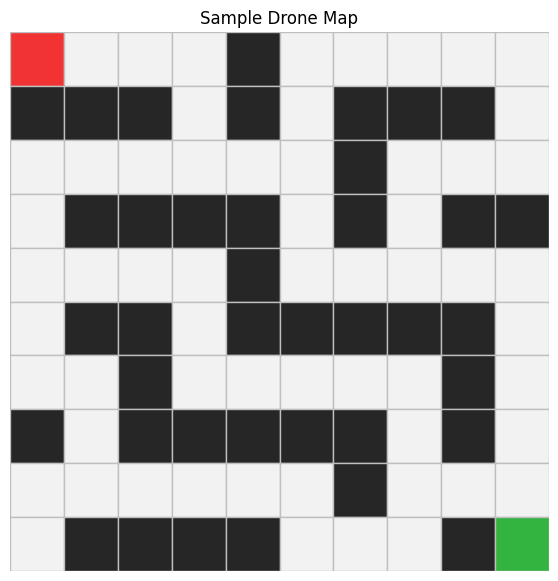

In [54]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

8. The Shared expand Method

In [55]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

9. Breadth-First Search (BFS)

In [56]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        initial_node = Node(state=problem.initial_state())
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="Success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
            )

        frontier = deque([initial_node])
        reached = {initial_node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="Success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                    )
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="Failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
        )

        raise NotImplementedError("Complete BreadthFirstSearch.search")

10. Depth-First Search (DFS)

In [57]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.

        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.

        initial_node = Node(state=problem.initial_state())
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="Success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
            )

        frontier = [initial_node]
        reached = {initial_node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            initial_node = frontier.pop()
            nodes_expanded += 1
            for child in self.expand(problem, initial_node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="Success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                    )
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="Failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
        )

        raise NotImplementedError("Complete DepthFirstSearch.search")

11. Depth-Limited Search (DLS)

In [58]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        status_map = {"success": "Success", "cutoff": "Cutoff", "failure": "Failure"}
        return SearchResult(
            algorithm=algorithm,
            status=status_map.get(status, status),
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")
        if problem.is_goal(node.state):
            return node, "success"
        elif node.depth >= limit:
            return None, "cutoff"
        else:
            metrics["nodes_expanded"] += 1
            cutoff_occurred = False
            for child in self.expand(problem, node):
                if state_is_on_path(node, child.state):
                    continue
                metrics["max_stack_size"] = max(
                    metrics["max_stack_size"], current_stack_size + 1
                )

                result, status = self._recursive_dls(
                    problem=problem,
                    node=child,
                    limit=limit,
                    metrics=metrics,
                    current_stack_size=current_stack_size + 1,
                )
                if status == "success":
                    return result, "success"
                elif status == "cutoff":
                    cutoff_occurred = True
            if cutoff_occurred:
                return None, "cutoff"
            else:
                return None, "failure"

12. Iterative Deepening Search (IDS)

In [59]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

        iteration_log = []
        for limit in range(max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)
            iteration_log.append(result_to_row(result))

            if result.status == "Success":
                return SearchResult(
                    algorithm=algorithm,
                    status="Success",
                    solution=result.solution,
                    nodes_expanded=sum(r["Nodes expanded"] for r in iteration_log),
                    max_frontier_size=max(
                        r["Max frontier/stack"] for r in iteration_log
                    ),
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )

            elif result.status == "Failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="Failure",
                    solution=None,
                    nodes_expanded=sum(r["Nodes expanded"] for r in iteration_log),
                    max_frontier_size=max(
                        r["Max frontier/stack"] for r in iteration_log
                    ),
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )
        return SearchResult(
            algorithm=algorithm,
            status="Cutoff",
            solution=None,
            nodes_expanded=sum(r["Nodes expanded"] for r in iteration_log),
            max_frontier_size=max(r["Max frontier/stack"] for r in iteration_log),
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log,
        )

        raise NotImplementedError("Complete IterativeDeepeningSearch.search")

13. Run the Algorithms on the Sample Map

In [60]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,18.0,18.0,50,5,0
1,DFS,Success,NaN,18.0,18.0,18,4,0
2,DLS,Cutoff,10.0,NaN,NaN,16,11,0
3,IDS,Success,18.0,18.0,18.0,356,19,0


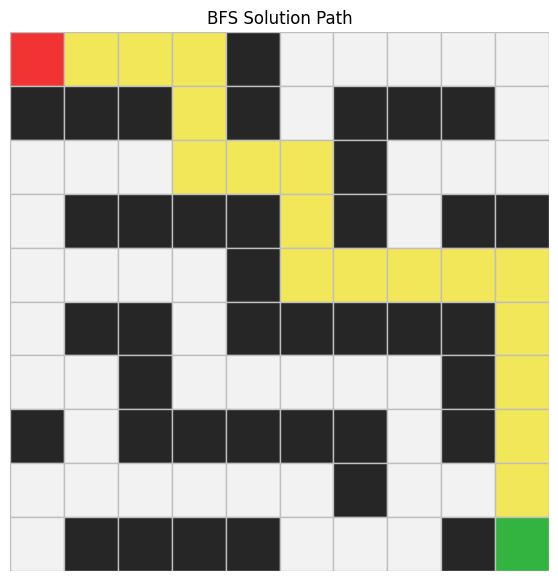

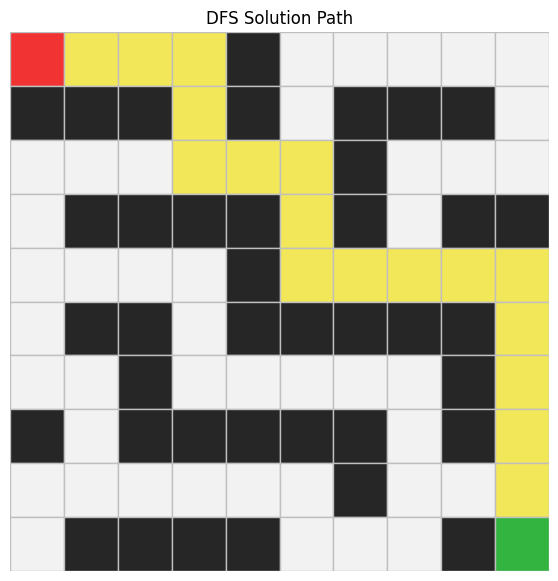

In [61]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

14. Create Your Own Maps

In [95]:
# TODO 10:
# Create your first custom map here.


# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
# custom_results_1 = [
#     bfs.search(custom_problem_1),
#     dfs.search(custom_problem_1),
#     dls.search(custom_problem_1, limit=20),
#     ids.search(custom_problem_1, max_depth=40),
# ]
# show_results(custom_results_1)

custom_grid_1 = [
    # 0  1  2  3  4  5  6  7  8  9  10 11 12 13 14
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0],  # 0  KFC 🍗
    [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0],  # 1
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],  # 2
    [1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],  # 3
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # 4
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0],  # 5
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 6
    [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1],  # 7
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 8
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0],  # 9
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],  # 10
    [1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0],  # 11
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 12
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],  # 13
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 14  🏠 HOUSE
]

custom_start_1 = (0, 0)  # KFC location
custom_goal_1 = (14, 14)  # House location

# Run the algorithms
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

# Run all algorithms on your custom map
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=30),
    ids.search(custom_problem_1, max_depth=50),
]

show_results(custom_results_1)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,28,28,104,9,0
1,DFS,Success,NaN,60,60,128,9,0
2,DLS,Success,30.0,28,28,185,31,0
3,IDS,Success,28.0,28,28,1301,29,0


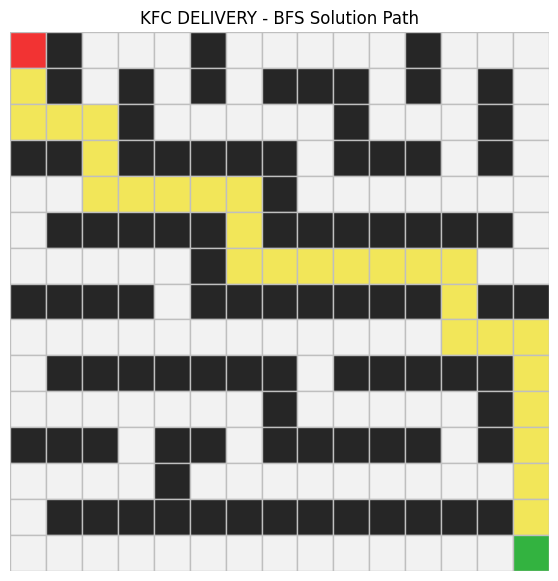

In [100]:
bfs_result_1 = custom_results_1[0]
dfs_result_1 = custom_results_1[1]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=bfs_result_1.path,
    title="KFC DELIVERY - BFS Solution Path",
)

## Map 1: KFC Delivery 

Drone delivers from KFC to house through corridors. BFS finds shortest route. DFS takes longer paths. IDS balances speed and memory.

In [ ]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    # Replace this with your own grid.
]

custom_start_2 = None
custom_goal_2 = None

# Example after completing:
# custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
# custom_results_2 = [
#     bfs.search(custom_problem_2),
#     dfs.search(custom_problem_2),
#     dls.search(custom_problem_2, limit=20),
#     ids.search(custom_problem_2, max_depth=40),
# ]
# show_results(custom_results_2)

custom_grid_2 = [
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
]

custom_start_2 = (0, 0)  # Home
custom_goal_2 = (19, 19)  # Museum

# Run the algorithms
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)


# Run all algorithms on your custom map
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=50),
    ids.search(custom_problem_2, max_depth=80),
]

show_results(custom_results_2)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Success,NaN,38,38,167,10,0
1,DFS,Success,NaN,76,76,121,14,0
2,DLS,Success,50.0,50,50,212,51,0
3,IDS,Success,38.0,38,38,5870,39,0


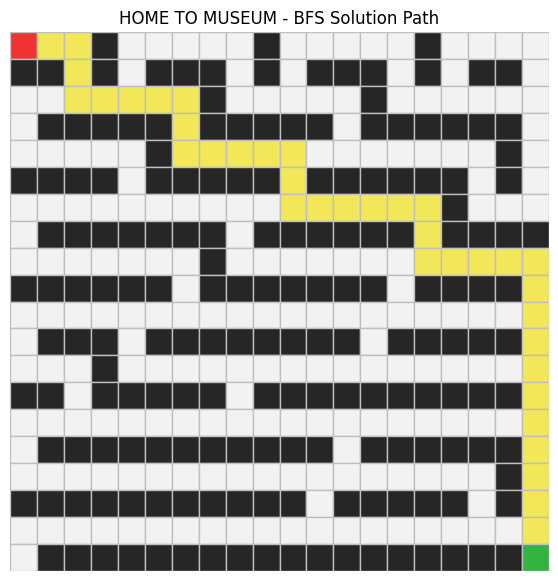

In [102]:
bfs_result_2 = custom_results_2[0]
dfs_result_2 = custom_results_2[1]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=bfs_result_2.path,
    title="HOME TO MUSEUM - BFS Solution Path",
)

## Map 2: Museum Trip (20×20)

Drone navigates maze-like city with dead ends. DFS wastes time in dead ends. BFS works but uses more memory. IDS is optimal for large complex maps.

15.1 Problem Formulation


State: A state is the drone’s current position on the grid, represented as a (row, col) coordinate.

Action: An action is a movement in one of the four directions: "UP", "DOWN", "LEFT", "RIGHT".

Result function: The result function takes a state and an action, and returns the new state after applying that action.

Separation of problem and algorithm: Separating the problem definition from the search algorithm makes the algorithms reusable. The same BFS or A* can work on different problems (grid, puzzle, road map) without rewriting the algorithm.

15.2 BFS
FIFO queue: BFS uses a queue so that nodes are expanded in the order they are discovered, ensuring level-by-level exploration.

Shortest path: On an unweighted grid, each move costs the same. BFS explores all nodes at depth d before moving to depth d+1, so the first time it finds the goal, it must be the shortest path.

Reached set: Prevents revisiting states, avoiding infinite loops and redundant work

15.3 DFS
Stack: DFS uses a stack (LIFO) so it always explores the most recently discovered node, diving deep before backtracking.

Shortest path guarantee: DFS is not guaranteed to find the shortest path, because it may follow a long branch before finding the goal.

Memory efficiency: DFS can use less memory than BFS when the branching factor is high, because it only stores one path at a time instead of all frontier nodes.

Bad performance: DFS can perform badly in large or infinite spaces, or when the goal is shallow but DFS explores deep irrelevant paths first.

15.4 DLS
Too small limit: If the depth limit is too small, the algorithm may stop before reaching the goal.

Cutoff: A cutoff means the search was stopped because the depth limit was reached, not because the goal was found.

Difference from DFS: DLS is DFS with a maximum depth restriction.

Path-cycle checking: Used to avoid revisiting states on the same path, which prevents infinite loops in recursive exploration.

15.5 IDS
Repeats DLS: IDS repeats DLS with increasing limits to gradually explore deeper levels until the goal is found.

Completeness: IDS is complete because eventually the limit will be large enough to reach the goal, even though small limits alone are incomplete.

Memory efficiency: IDS uses less memory than BFS because it behaves like DFS at each iteration.

Cost of repetition: IDS re-expands nodes multiple times from the root, which increases time cost compared to BFS.

15.6 Real-World Drone Context
Safer routes: In actual practice, routes can vary in safety, depending on weather, wind turbulence, restricted zones, and battery use. There could be a safer path even if longer than the path with fewer obstacles.

If all the moves cost the same and the minimum number of moves and the shortest path is all that matters, then BFS is the best suited algorithm as it guarantees the shortest path in terms of number of moves.

Depth restriction: If you wish to restrict the depth of the search conducted by the drone (such as battery saving or not going too far off course), then DLS is suitable since you can set a maximum depth.

Limitations of the grid model: The grid is a simplification. Real drones fly in the 3D space, encountering dynamic weather, changes of altitude and energy. These complexities are not factored into the grid.